#Machine Learning I - Fase 1 - Template


Nome: **DENISE ALMEIDA DE SOUZA**

### Análise Exploratória e Preparação dos Dados



### 1) Formatação dos atributos


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.utils import resample
from sklearn.preprocessing import MinMaxScaler

In [517]:
# 1.1) Visualização dos dados de cada coluna

df = pd.read_csv('../data/raw/titanic_modified.csv')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1069 entries, 0 to 1068
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1069 non-null   int64  
 1   Survived     1069 non-null   bool   
 2   Pclass       985 non-null    float64
 3   Name         1069 non-null   str    
 4   Sex          985 non-null    str    
 5   Age          855 non-null    str    
 6   SibSp        1069 non-null   int64  
 7   Parch        1069 non-null   int64  
 8   Ticket       1069 non-null   str    
 9   Fare         1069 non-null   float64
 10  Cabin        248 non-null    str    
 11  Embarked     983 non-null    str    
 12  day          1069 non-null   int64  
 13  month        1069 non-null   int64  
 14  year         1069 non-null   int64  
 15  time         1069 non-null   str    
 16  cost         202 non-null    float64
 17  budget       128 non-null    float64
dtypes: bool(1), float64(4), int64(6), str(7)
memory usage: 143.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,day,month,year,time,cost,budget
0,1,False,3.0,"Braund, Mr. Owen Harris",male,22 years old,1,0,A/5 21171,7.2500,NaN,S,10,1,1912,01:17,0.86425,NaN
1,2,True,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,Age 38,1,0,PC 17599,71.2833,C85,C,5,1,1912,22:46,NaN,NaN
2,3,True,3.0,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S,11,3,1912,12:27,NaN,0.999252
3,4,True,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S,18,3,1912,23:49,NaN,NaN
4,5,False,3.0,"Allen, Mr. William Henry",male,35 years old,0,0,373450,8.0500,NaN,S,14,1,1912,02:01,NaN,NaN


In [518]:
df.describe()

,PassengerId,Pclass,SibSp,Parch,Fare,day,month,year,cost,budget
count,1069.000000,985.000000,1069.000000,1069.000000,1069.000000,1069.000000,1069.000000,1069.0,202.000000,128.000000
mean,444.918616,2.338071,0.502339,0.382601,31.964238,10.713751,1.973807,1912.0,-0.158032,-0.044619
std,257.535154,0.827882,1.050791,0.815645,48.138574,5.980493,0.819511,0.0,1.018425,1.003088
min,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1912.0,-2.658628,-2.832182
25%,223.000000,2.000000,0.000000,0.000000,7.895800,6.000000,1.000000,1912.0,-0.829477,-0.793220
50%,443.000000,3.000000,0.000000,0.000000,14.454200,11.000000,2.000000,1912.0,-0.165283,-0.105831
75%,667.000000,3.000000,1.000000,0.000000,31.275000,16.000000,3.000000,1912.0,0.598523,0.723545
max,891.000000,3.000000,8.000000,6.000000,512.329200,20.000000,3.000000,1912.0,2.634966,2.217751


In [519]:
# 1.2) Formatação de cada coluna

df.drop(columns=['Name', 'SibSp', 'Parch', 'Ticket', 'Cabin', 'time', 'budget', 'cost', 'day' , 'month', 'year'], inplace=True)
df['Survived'] = df['Survived'].astype(int)
df['Age'] = df['Age'].astype(str).str.extract('(\d+)').astype(float)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked
0,1,0,3.0,0.0,22.0,7.2500,0.0
1,2,1,1.0,1.0,38.0,71.2833,1.0
2,3,1,3.0,1.0,26.0,7.9250,0.0
3,4,1,1.0,1.0,35.0,53.1000,0.0
4,5,0,3.0,0.0,35.0,8.0500,0.0


In [520]:
# 1.3) Remoção das linhas repetidas

total_duplicadas = df.duplicated().sum()
print(f"Quantidade de linhas totalmente duplicadas encontradas: {total_duplicadas}")

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

Quantidade de linhas totalmente duplicadas encontradas: 178


,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked
0,1,0,3.0,0.0,22.0,7.2500,0.0
1,2,1,1.0,1.0,38.0,71.2833,1.0
2,3,1,3.0,1.0,26.0,7.9250,0.0
3,4,1,1.0,1.0,35.0,53.1000,0.0
4,5,0,3.0,0.0,35.0,8.0500,0.0


In [521]:
# 1.4) Transformação das colunas categóricas para numéricas

print("\n--- Situação atual dos tipos de dados no Dataset ---")
df.info()


--- Situação atual dos tipos de dados no Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       823 non-null    float64
 3   Sex          823 non-null    float64
 4   Age          714 non-null    float64
 5   Fare         891 non-null    float64
 6   Embarked     821 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 48.9 KB


### 2) Análise e escolha dos atributos

Agora, você precisa analisar cada atributo para verificar quais possuem informação relevantes para classificar a coluna alvo.

Utilize as técnicas de visualização e análise de dados vistas em aula para realizar esse processo.

Ao final da análise, você deve escolher os atributos que considerou mais relevântes com base na análise realizada (JUSTIFIQUE A ESCOLHA DE CADA COLUNA)

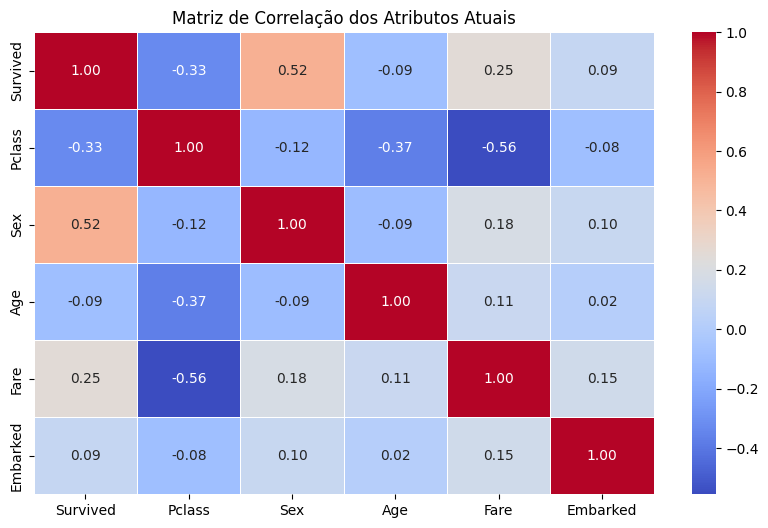

In [522]:
# 2.1) Visualização dos dados

plt.figure(figsize=(10, 6))

# Matriz de Correlação 

df_corr = df.drop(columns=['PassengerId'], errors='ignore').dropna()
correlation_matrix = df_corr.corr()

# Plotando o Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlação dos Atributos Atuais")
plt.show()


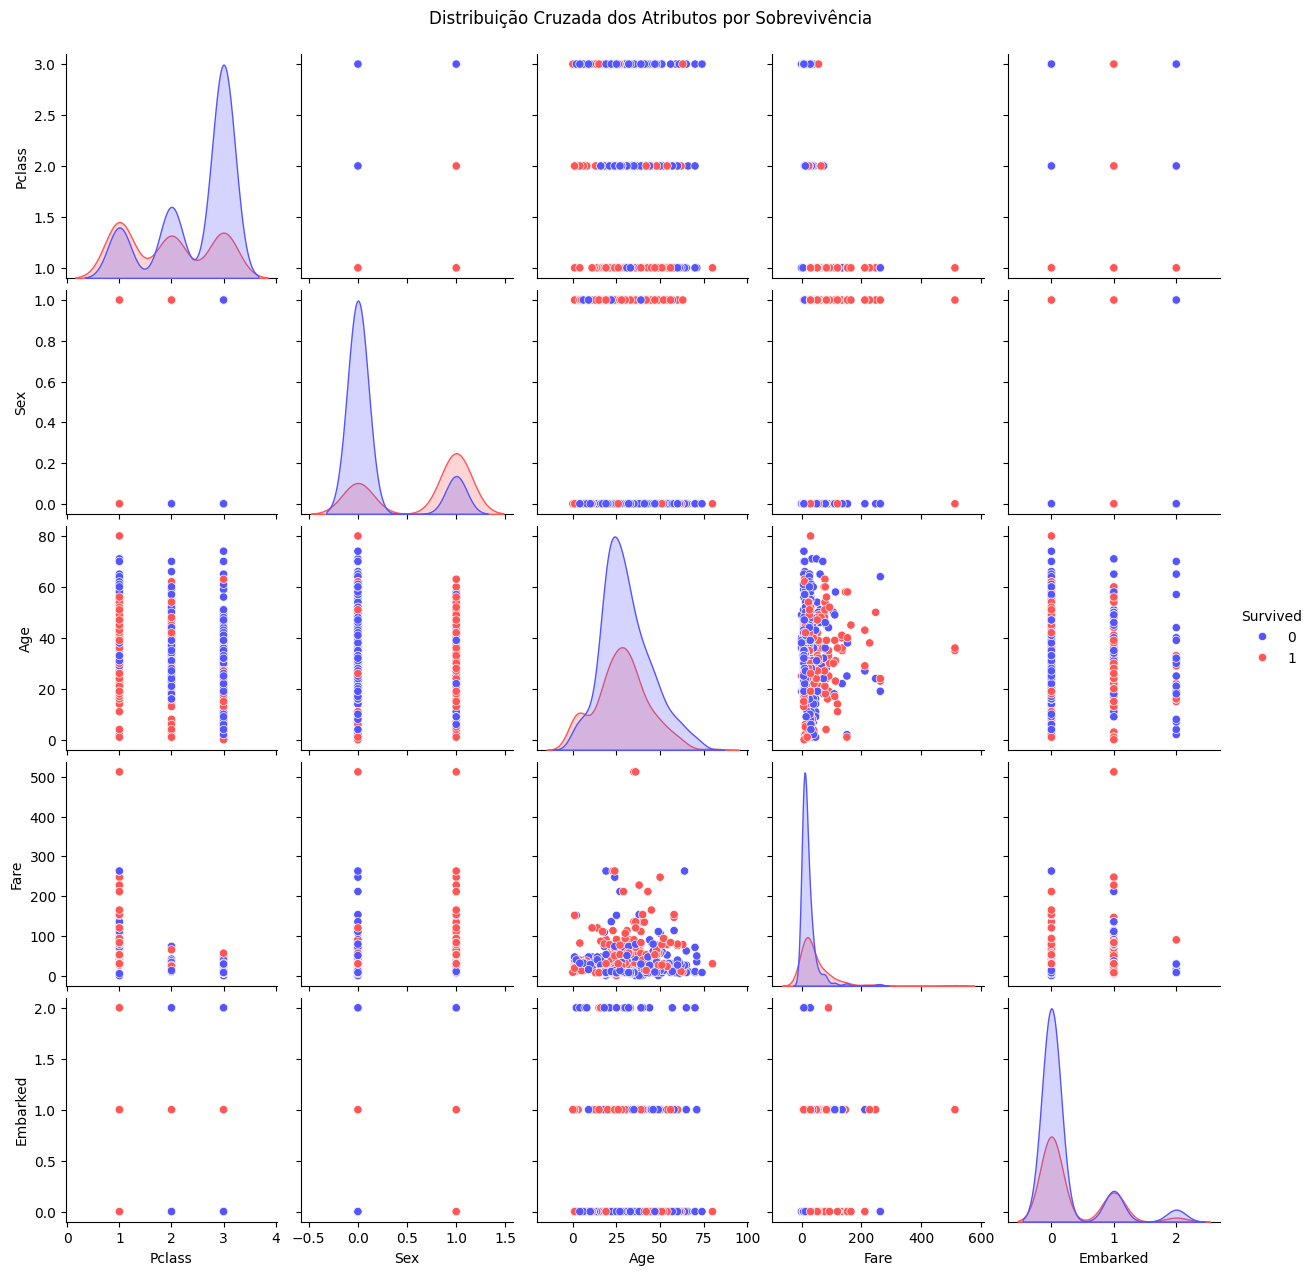

In [523]:
# Pairplot
colunas_principais = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Survived']
sns.pairplot(df[colunas_principais].dropna(), hue='Survived', palette='seismic', diag_kind='kde')
plt.suptitle("Distribuição Cruzada dos Atributos por Sobrevivência", y=1.02)
plt.show()

### Análise sobre possiveis relação encontradas

A partir da análise visual da Matriz de Correlação e do Pairplot, conseguimos extrair insights estatísticos claros e diretamente ligados à sobrevivência (Survived):

Gênero (Sex = 0.52):

Esta é a maior correlação de atributos do dataset, observando que foram mapeados os valores 1 para Mulheres e 0 para os Homens, o valor de 0.52 prova numericamente um uso de estratégia de salvar as mulheres primeiro. No gráfico Pairplot (linha/coluna do Sex), o pico azul (sobreviventes) é massivo no valor 1.0, enquanto o pico vermelho(Homens) domina o valor 0.0.

O peso da classe social (Pclass = -0.33 e Fare = 0.25): A correlação de Pclass é de -0.33. O sinal negativo indica uma relação inversa: quanto menor o número da classe (1ª classe), maior a taxa de sobrevivência. O Pairplot confirma isso mostrando uma montanha vermelha (mortes) gigantesca na 3ª classe (3.0). Complementando isso, a tarifa (Fare) tem correlação positiva de 0.25, mostrando que quem pagou mais caro teve mais chances de se salvar.

A nuance da Idade (Age = -0.09): A correlação linear parece baixa (-0.09), mas ao observar o gráfico de densidade da Age no Pairplot, vemos um comportamento não-linear interessante: há uma concentração de sobreviventes (linha azul) na extremidade esquerda do gráfico, que representa o salvamento prioritário de crianças pequenas.

### 3) Preenchimento de dados faltantes

In [524]:
# 3.1) Gerar o dataset sem as colunas com dados faltantes
df.isnull().sum()

PassengerId      0
Survived         0
Pclass          68
Sex             68
Age            177
Fare             0
Embarked        70
dtype: int64

In [525]:
colunas_com_nulos = df.columns[df.isnull().sum() > 0]

df2 = df.drop(columns=colunas_com_nulos)

df2.head()

,PassengerId,Survived,Fare
0,1,0,7.2500
1,2,1,71.2833
2,3,1,7.9250
3,4,1,53.1000
4,5,0,8.0500


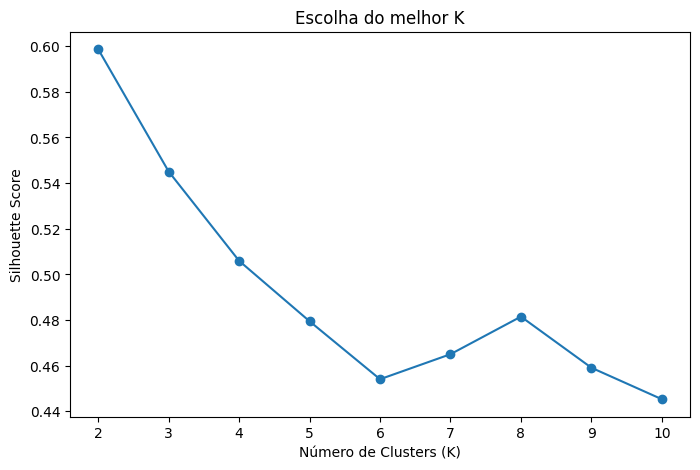

In [526]:
# 3.2) Aplicar o K-means no novo dataset (explorando o melhor valor de K)

scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(df2)

    score = silhouette_score(df2, labels)
    scores.append(score)

# Visualização
plt.figure(figsize=(8,5))
plt.plot(range(2,11), scores, marker='o')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Escolha do melhor K')
plt.show()

In [527]:
melhor_k = 2
kmeans = KMeans(
    n_clusters=melhor_k,
    random_state=42,
    n_init=10
)

df2['Cluster'] = kmeans.fit_predict(df2)

df['Cluster'] = df2['Cluster']
df.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,Cluster
0,1,0,3.0,0.0,22.0,7.2500,0.0,0
1,2,1,1.0,1.0,38.0,71.2833,1.0,0
2,3,1,3.0,1.0,26.0,7.9250,0.0,0
3,4,1,1.0,1.0,35.0,53.1000,0.0,0
4,5,0,3.0,0.0,35.0,8.0500,0.0,0


In [528]:
# 3.3) Cálcular um atributo estatístico (média, moda, mediana, etc), no dataset original, das colunas com dados faltantes
estatisticas = {}

estatisticas['Age'] = (
    df[df['Age'].notna()]
    .groupby('Cluster')['Age']
    .median()
)

for coluna in ['Pclass', 'Sex', 'Embarked']:
    estatisticas[coluna] = (
        df[df[coluna].notna()]
        .groupby('Cluster')[coluna]
        .agg(lambda x: x.mode()[0])
    )

estatisticas

{'Age': Cluster
 0    28.0
 1    30.0
 Name: Age, dtype: float64,
 'Pclass': Cluster
 0    3.0
 1    3.0
 Name: Pclass, dtype: float64,
 'Sex': Cluster
 0    0.0
 1    0.0
 Name: Sex, dtype: float64,
 'Embarked': Cluster
 0    0.0
 1    0.0
 Name: Embarked, dtype: float64}

Para a variável Age foi utilizada a mediana dos valores pertencentes ao mesmo cluster. A mediana foi escolhida por ser uma medida robusta e menos sensível à influência de valores extremos (outliers), comuns em variáveis numéricas contínuas.

Para as variáveis Pclass, Sex e Embarked foi utilizada a moda, pois representam categorias codificadas numericamente. Nesse contexto, a moda permite identificar a categoria mais frequente dentro de cada cluster, preservando melhor as características predominantes do grupo.

In [529]:
# 3.4) Preencher os valores das linhas com dados faltantes com o atributo estatístico referente ao seu grupo do K-means

df['Age'] = df['Age'].fillna(
    df['Cluster'].map(estatisticas['Age'])
)

df['Pclass'] = df['Pclass'].fillna(
    df['Cluster'].map(estatisticas['Pclass'])
)

df['Sex'] = df['Sex'].fillna(
    df['Cluster'].map(estatisticas['Sex'])
)

df['Embarked'] = df['Embarked'].fillna(
    df['Cluster'].map(estatisticas['Embarked'])
)

df.drop(columns=['Cluster'], inplace=True)

In [530]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
Fare           0
Embarked       0
dtype: int64

# 4) Escala dos atributos

Agora, você precisa reescalar os dados, para que os algoritmos consigam aprender as relações entre os dados sem muito ruído e melhora a classificação.

Lembre-se de verificar e tratar colunas com outliers.

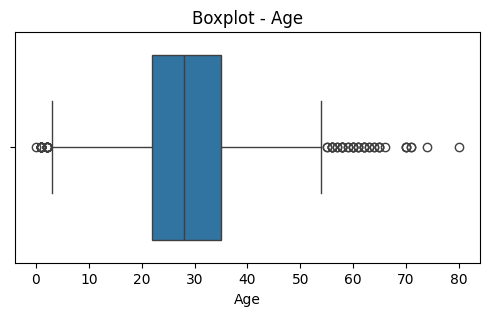

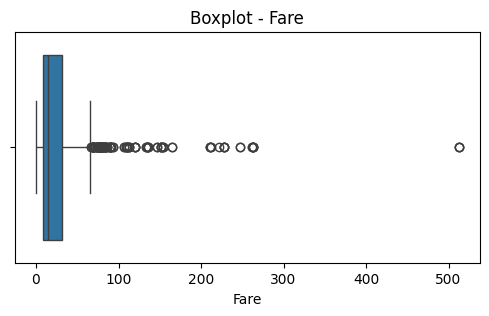

In [531]:
## 4.1) Verificar quais dados possuem outliers e tratar de acordo

colunas_numericas = ['Age', 'Fare']

for coluna in colunas_numericas:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[coluna])
    plt.title(f'Boxplot - {coluna}')
    plt.show()

In [532]:
for coluna in ['Age', 'Fare']:

    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    df[coluna] = df[coluna].clip(
        lower=limite_inferior,
        upper=limite_superior
    )

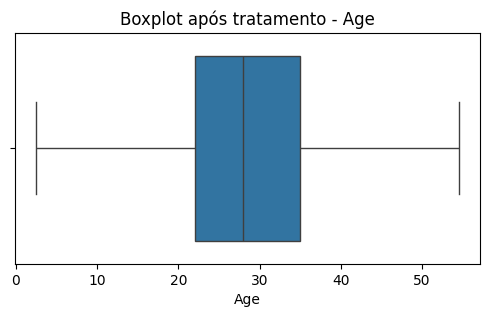

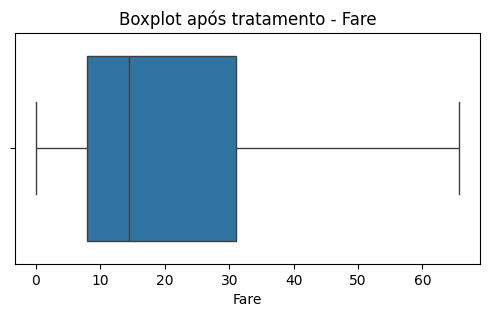

In [533]:
for coluna in ['Age', 'Fare']:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[coluna])
    plt.title(f'Boxplot após tratamento - {coluna}')
    plt.show()

In [ ]:
## 4.2) Reescalar os dados

scaler = MinMaxScaler()

colunas_features = df.columns.drop('Survived')

df[colunas_features] = scaler.fit_transform(df[colunas_features])
df.describe()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.500000,0.383838,0.699776,0.296296,0.514105,0.366375,0.161616
std,0.289162,0.486592,0.404247,0.456880,0.232126,0.312056,0.308544
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250000,0.000000,0.500000,0.000000,0.375000,0.120522,0.000000
50%,0.500000,0.000000,1.000000,0.000000,0.490385,0.220223,0.000000
75%,0.750000,1.000000,1.000000,1.000000,0.625000,0.472313,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [535]:
classe_0 = df[df['Survived'] == 0]
classe_1 = df[df['Survived'] == 1]

classe_1_balanceada = resample(
    classe_1,
    replace=True,
    n_samples=len(classe_0),
    random_state=42
)

df_balanceado = pd.concat(
    [classe_0, classe_1_balanceada]
)

df_balanceado = df_balanceado.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [536]:
print("===== VALIDAÇÃO FINAL =====\n")

# 1. Duplicados
print("Linhas duplicadas:")
print(df_balanceado.duplicated().sum())

# 2. Dados faltantes
print("\nValores faltantes por coluna:")
print(df_balanceado.isnull().sum())

# 3. Tipos das colunas
print("\nTipos de dados:")
print(df_balanceado.dtypes)

# 4. Estatísticas após normalização
print("\nResumo estatístico:")
print(df_balanceado.describe())

# 5. Balanceamento da variável alvo
print("\nDistribuição da variável Survived:")
print(df_balanceado['Survived'].value_counts())

===== VALIDAÇÃO FINAL =====

Linhas duplicadas:
279

Valores faltantes por coluna:
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
Fare           0
Embarked       0
dtype: int64

Tipos de dados:
PassengerId    float64
Survived         int64
Pclass         float64
Sex            float64
Age            float64
Fare           float64
Embarked       float64
dtype: object

Resumo estatístico:
       PassengerId     Survived       Pclass          Sex          Age  \
count  1098.000000  1098.000000  1098.000000  1098.000000  1098.000000   
mean      0.502591     0.500000     0.663024     0.358834     0.513031   
std       0.283372     0.500228     0.421417     0.479877     0.229028   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.272191     0.000000     0.500000     0.000000     0.375000   
50%       0.498315     0.500000     1.000000     0.000000     0.490385   
75%       0.744663     1.000000     1.000000     1.000

In [537]:
# 6.1) Salvar o dataset final preparado

df_balanceado.to_csv(
    '../data/processed/titanic_prepared.csv',
    index=False
)

print("Dataset final salvo com sucesso!")

Dataset final salvo com sucesso!
